# Evaluación del modelo clasificador de riesgo IA

En este notebook evaluamos el modelo entrenado sobre el conjunto de test.

Métricas:
1. Classification report (precision, recall, f1 por clase)
2. F1-score macro
3. Matriz de confusión
4. Curva ROC multiclase (One-vs-Rest)
5. Análisis de errores
6. Registro de métricas en MLflow

In [12]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [13]:
import sys
import os

# Localizar src/classifier/ de forma robusta y ajustar cwd al directorio
# de este notebook para que rutas relativas (datasets/, data/, model/) funcionen
# independientemente de desde donde se lance Jupyter/VS Code.
_cwd = os.getcwd()
_candidates = [
    os.path.join(_cwd, "src", "classifier"),
    os.path.abspath(".."),
    os.path.abspath("."),
]
for _p in _candidates:
    if os.path.isfile(os.path.join(_p, "functions.py")):
        if _p not in sys.path:
            sys.path.insert(0, _p)
        # Cambiar cwd al directorio de este notebook
        os.chdir(os.path.join(_p, "classifier_ultimo_dataset"))
        break

import functions  # noqa: E402
functions.MLFLOW_EXPERIMENT = "clasificador_riesgo_ultimo_dataset"
functions._DATASET_TAGS = {"dataset_type": "ultimo", "dataset_source": "dataset_sintetico_v2"}

## 1. Carga del modelo y datos de test

In [14]:
from pathlib import Path
import pandas as pd
import joblib
from scipy.sparse import csr_matrix, hstack

# Cargar modelo y TF-IDF
modelo = joblib.load("model/modelo_baseline.joblib")
tfidf  = joblib.load("model/tfidf_vectorizer.joblib")
print("Artefactos cargados correctamente.")

test_path = Path("data/processed/test.csv")
if not test_path.exists():
    raise FileNotFoundError(
        f"Datos de test no encontrados: {test_path}. "
        "Ejecuta el preprocesado antes de evaluar."
    )

test_df     = pd.read_csv(test_path)
X_test_text = test_df["text_final"]
y_test      = test_df["etiqueta"]

X_test_tfidf = tfidf.transform(X_test_text)

# Detectar columnas igual que en entrenamiento (adaptativo)
_cols   = set(test_df.columns) - {"text_final", "etiqueta"}
NUM_COLS = [c for c in ["longitud", "num_articles"] if c in _cols]

parts = [X_test_tfidf]

ohe_path = Path("model/ohe_encoder.joblib")
ohe = None
if ohe_path.exists():
    ohe = joblib.load(ohe_path)
    # Usar exactamente las columnas con las que se entrenó el OHE
    ohe_cols = list(ohe.feature_names_in_) if hasattr(ohe, "feature_names_in_") else []
    if ohe_cols:
        cat_test = ohe.transform(test_df[ohe_cols])
        parts.append(cat_test)
        print(f"OHE cols: {ohe_cols} → {cat_test.shape[1]} features")

if NUM_COLS:
    num_test = csr_matrix(test_df[NUM_COLS].values.astype(float))
    parts.append(num_test)
    print(f"Numéricas: {NUM_COLS}")

X_test_final = hstack(parts) if len(parts) > 1 else parts[0]
print(f"TF-IDF: {X_test_tfidf.shape[1]} | Total: {X_test_final.shape[1]} features")
print(f"\nTest: {len(X_test_text)} muestras | Clases: {sorted(y_test.unique())}")

Artefactos cargados correctamente.
OHE cols: ['sector', 'tipo_datos'] → 23 features
Numéricas: ['longitud']
TF-IDF: 1700 | Total: 1724 features

Test: 43 muestras | Clases: ['alto_riesgo', 'inaceptable', 'riesgo_limitado', 'riesgo_minimo']


## 2. Classification report y F1-score macro

In [15]:
from functions import evaluar_modelo

y_pred, report_dict = evaluar_modelo(modelo, X_test_final, y_test)

=== Resultados en TEST ===

                 precision    recall  f1-score   support

    alto_riesgo       1.00      0.91      0.95        11
    inaceptable       0.83      1.00      0.91        10
riesgo_limitado       0.80      0.73      0.76        11
  riesgo_minimo       0.82      0.82      0.82        11

       accuracy                           0.86        43
      macro avg       0.86      0.86      0.86        43
   weighted avg       0.86      0.86      0.86        43

F1-score macro (test): 0.8604



## 3. Matriz de confusión

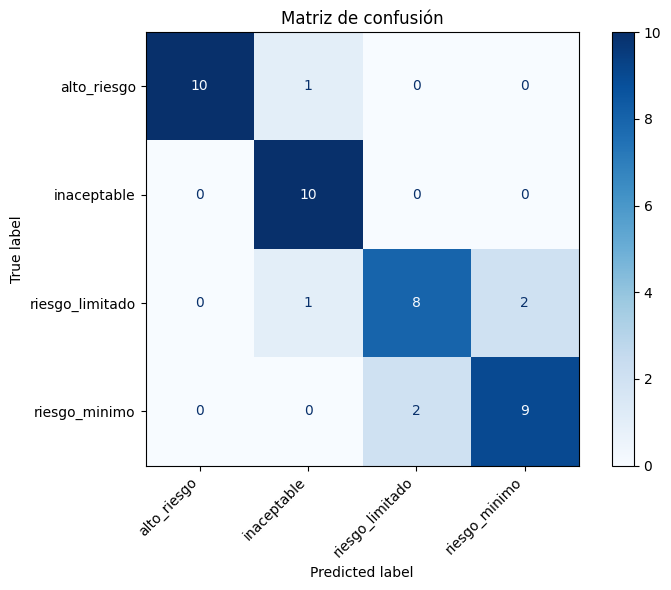

In [16]:
from functions import mostrar_matriz_confusion

clases = sorted(y_test.unique())
fig_cm = mostrar_matriz_confusion(y_test, y_pred, labels=clases)

## 4. Curva ROC multiclase

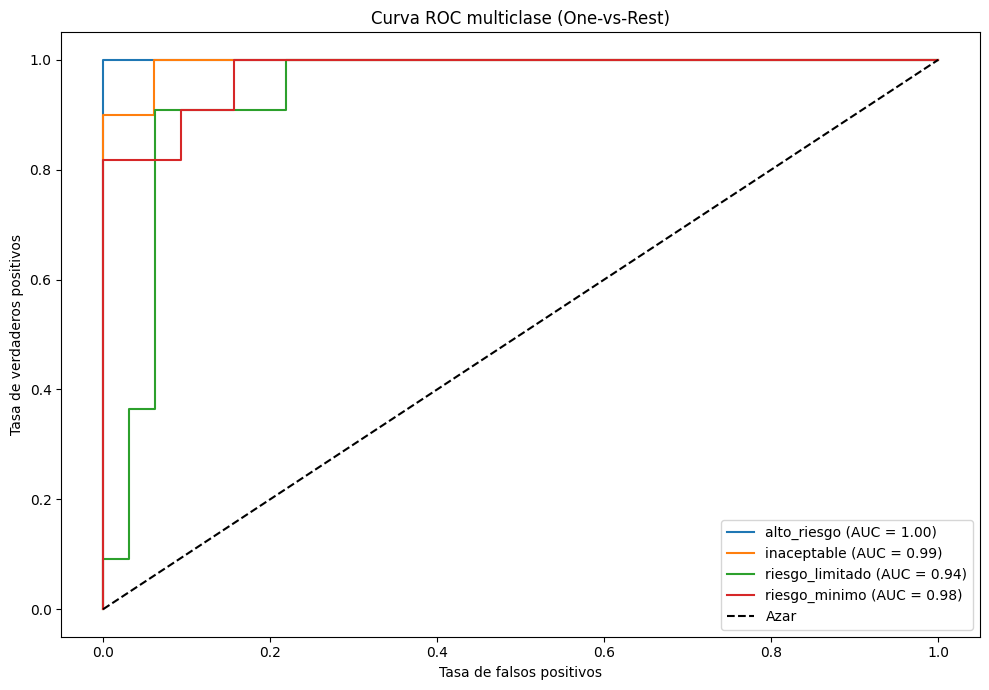


ROC AUC macro: 0.9772
  alto_riesgo: 1.0000
  inaceptable: 0.9939
  riesgo_limitado: 0.9375
  riesgo_minimo: 0.9773


In [17]:
from functions import plot_curva_roc_multiclase

fig_roc, roc_auc_dict = plot_curva_roc_multiclase(modelo, X_test_final, y_test)

## 5. Análisis de errores

In [18]:
from functions import analisis_errores

df_errores = analisis_errores(modelo, X_test_final, y_test, X_test_text=X_test_text)

Total de errores: 6 de 43 (14.0%)

Confusiones más frecuentes:
etiqueta_real    etiqueta_predicha
riesgo_minimo    riesgo_limitado      2
riesgo_limitado  riesgo_minimo        2
                 inaceptable          1
alto_riesgo      inaceptable          1
dtype: int64

Ejemplos mal clasificados:
  Real: riesgo_minimo | Predicho: riesgo_limitado
  Texto: desarrollo herramienta resume artículos prensa generar boletín diario personalizado...

  Real: riesgo_minimo | Predicho: riesgo_limitado
  Texto: versión beta herramienta analiza rendimiento campañas email marketing sugiere mejoras...

  Real: riesgo_limitado | Predicho: inaceptable
  Texto: implementación herramienta análisis sentimiento evalúa recepción pública políticas gubernamentales partir redes sociales...

  Real: riesgo_limitado | Predicho: riesgo_minimo
  Texto: prototipo asistente ayuda agricultores identificar plagas cultivos partir fotos hojas...

  Real: riesgo_limitado | Predicho: riesgo_minimo
  Texto: aplicación perm

## 6. Registro de métricas en MLflow

In [19]:
# ── MLflow (solo falla esta celda si el servidor no está disponible) ──
import numpy as np
import mlflow
from functions import configure_mlflow, MLFLOW_EXPERIMENT

# Guardar gráficos localmente (no depende del servidor)
fig_cm.savefig("model/matriz_confusion.png", dpi=150, bbox_inches="tight")
fig_roc.savefig("model/curva_roc.png", dpi=150, bbox_inches="tight")

try:
    configure_mlflow()
    mlflow.set_experiment(MLFLOW_EXPERIMENT)

    with mlflow.start_run(run_name="evaluacion_test"):
        mlflow.log_metric("test_f1_macro",        report_dict["macro avg"]["f1-score"])
        mlflow.log_metric("test_accuracy",         report_dict["accuracy"])
        mlflow.log_metric("test_precision_macro",  report_dict["macro avg"]["precision"])
        mlflow.log_metric("test_recall_macro",     report_dict["macro avg"]["recall"])

        for clase, auc_val in roc_auc_dict.items():
            mlflow.log_metric(f"test_roc_auc_{clase}", auc_val)
        mlflow.log_metric("test_roc_auc_macro", np.mean(list(roc_auc_dict.values())))

        mlflow.log_artifact("model/matriz_confusion.png")
        mlflow.log_artifact("model/curva_roc.png")

        print("✓ Métricas de test registradas en MLflow")
        print(f"  F1-score macro: {report_dict['macro avg']['f1-score']:.4f}")
        print(f"  Run ID: {mlflow.active_run().info.run_id}")
except Exception as e:
    print(f"⚠ MLflow no disponible: {e}")

Password obtenida desde variable de entorno local.
MLflow configurado correctamente → https://18.201.64.41/
⚠ MLflow no disponible: API request to https://18.201.64.41/api/2.0/mlflow/experiments/get-by-name failed with timeout exception HTTPSConnectionPool(host='18.201.64.41', port=443): Max retries exceeded with url: /api/2.0/mlflow/experiments/get-by-name?experiment_name=clasificador_riesgo_ultimo_dataset (Caused by ConnectTimeoutError(<HTTPSConnection(host='18.201.64.41', port=443) at 0x22f63beba70>, 'Connection to 18.201.64.41 timed out. (connect timeout=120)')). To increase the timeout, set the environment variable MLFLOW_HTTP_REQUEST_TIMEOUT (default: 120, type: int) to a larger value.


Instala las dependencias desde `requirements.txt` antes de ejecutar este notebook:
```bash
pip install -r requirements.txt
```

## 7. Conclusiones

Documentar aquí las conclusiones tras observar las métricas:
- ¿Qué clases se confunden más entre sí?
- ¿El modelo generaliza bien o muestra signos de overfitting?
- ¿Qué mejoras se podrían probar en iteraciones futuras?